<a href="https://colab.research.google.com/github/jayshri-05/ADG-reqruitement/blob/main/ML_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

In [107]:
df = pd.read_csv("heart.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [108]:
df.head()
print("Shape of dataset:", df.shape)

Shape of dataset: (1025, 14)


In [109]:
print("Column names:")
print(df.columns.tolist())

Column names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [110]:
print("Data types of all columns:")
print(df.dtypes)

Data types of all columns:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


In [111]:
question_marks = (df == '?').sum()
print(question_marks)

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [112]:
(df == '?').sum().sum()

np.int64(0)

In [113]:
print(df.isnull().sum())


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [114]:
for column in df.columns:
    print("\n", column)
    print(df[column].unique())


 age
[52 53 70 61 62 58 55 46 54 71 43 34 51 50 60 67 45 63 42 44 56 57 59 64
 65 41 66 38 49 48 29 37 47 68 76 40 39 77 69 35 74]

 sex
[1 0]

 cp
[0 1 2 3]

 trestbps
[125 140 145 148 138 100 114 160 120 122 112 132 118 128 124 106 104 135
 130 136 180 129 150 178 146 117 152 154 170 134 174 144 108 123 110 142
 126 192 115  94 200 165 102 105 155 172 164 156 101]

 chol
[212 203 174 294 248 318 289 249 286 149 341 210 298 204 308 266 244 211
 185 223 208 252 209 307 233 319 256 327 169 131 269 196 231 213 271 263
 229 360 258 330 342 226 228 278 230 283 241 175 188 217 193 245 232 299
 288 197 315 215 164 326 207 177 257 255 187 201 220 268 267 236 303 282
 126 309 186 275 281 206 335 218 254 295 417 260 240 302 192 225 325 235
 274 234 182 167 172 321 300 199 564 157 304 222 184 354 160 247 239 246
 409 293 180 250 221 200 227 243 311 261 242 205 306 219 353 198 394 183
 237 224 265 313 340 259 270 216 264 276 322 214 273 253 176 284 305 168
 407 290 277 262 195 166 178 141]

 fbs

In [115]:
print(df.nunique())

age          41
sex           2
cp            4
trestbps     49
chol        152
fbs           2
restecg       3
thalach      91
exang         2
oldpeak      40
slope         3
ca            5
thal          4
target        2
dtype: int64


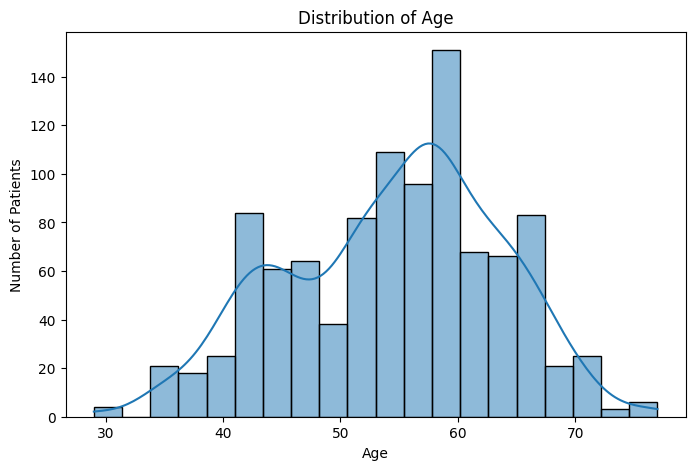

In [116]:
plt.figure(figsize=(8, 5))

sns.histplot(df['age'], bins=20, kde=True)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

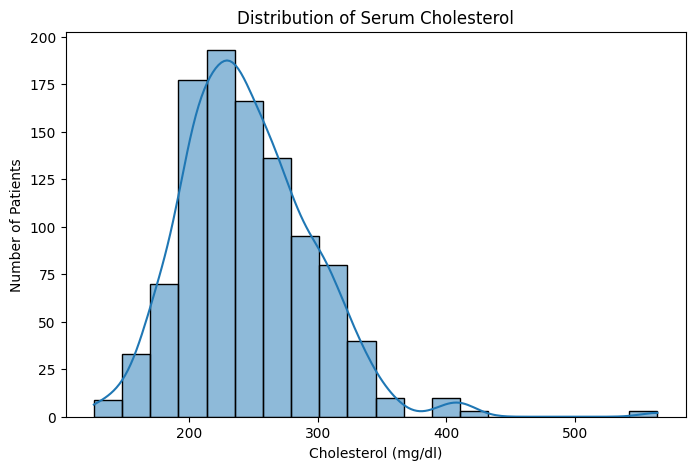

In [117]:
plt.figure(figsize=(8, 5))

sns.histplot(df['chol'], bins=20, kde=True)

plt.title("Distribution of Serum Cholesterol")
plt.xlabel("Cholesterol (mg/dl)")
plt.ylabel("Number of Patients")

plt.show()

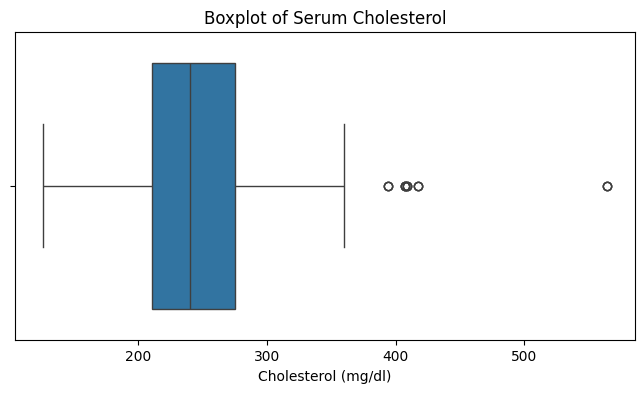

In [118]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df['chol'])

plt.title("Boxplot of Serum Cholesterol")
plt.xlabel("Cholesterol (mg/dl)")

plt.show()

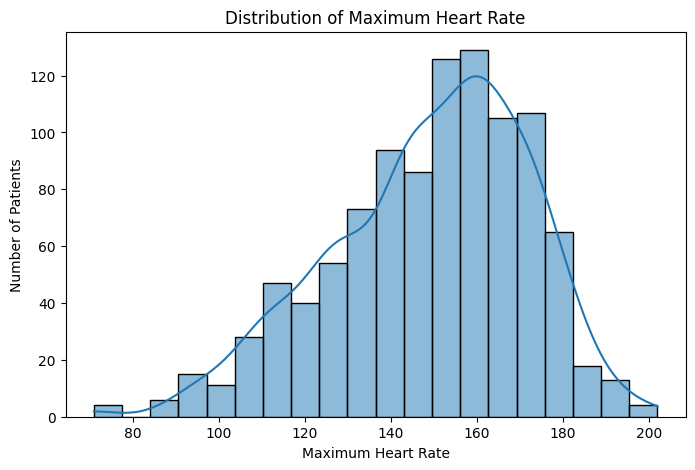

In [119]:
plt.figure(figsize=(8, 5))

sns.histplot(df['thalach'], bins=20, kde=True)

plt.title("Distribution of Maximum Heart Rate")
plt.xlabel("Maximum Heart Rate")
plt.ylabel("Number of Patients")

plt.show()

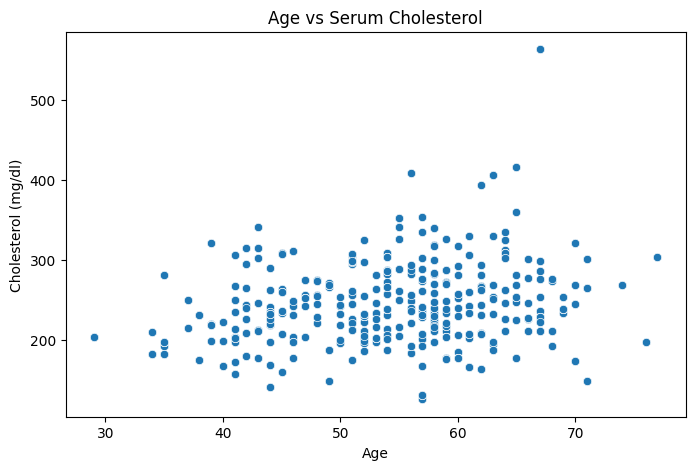

In [120]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='age',
    y='chol'
)

plt.title("Age vs Serum Cholesterol")
plt.xlabel("Age")
plt.ylabel("Cholesterol (mg/dl)")

plt.show()

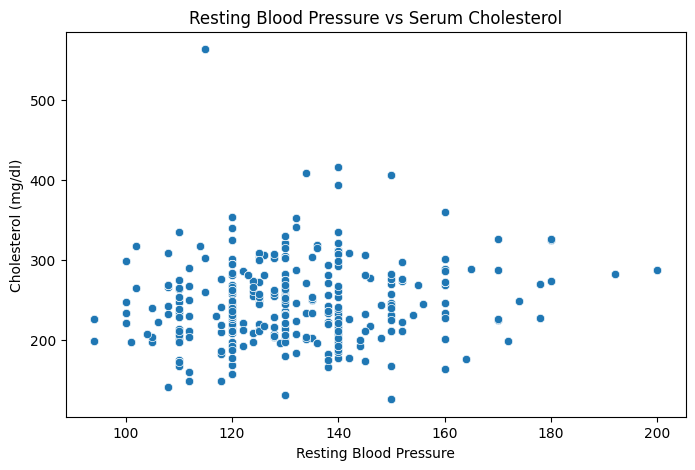

In [121]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='trestbps',
    y='chol'
)

plt.title("Resting Blood Pressure vs Serum Cholesterol")
plt.xlabel("Resting Blood Pressure")
plt.ylabel("Cholesterol (mg/dl)")

plt.show()

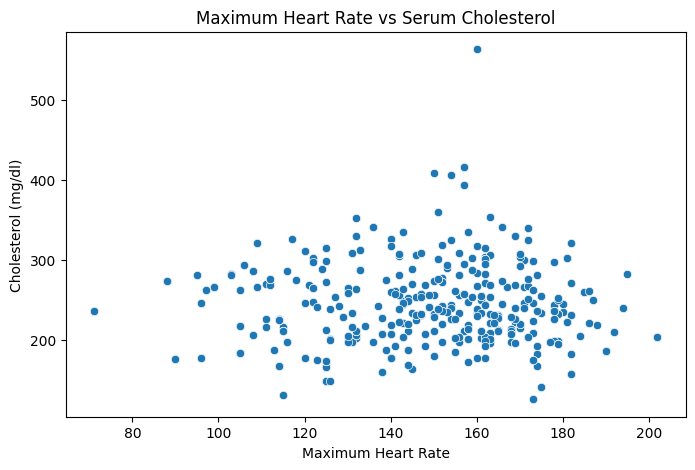

In [122]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='thalach',
    y='chol'
)

plt.title("Maximum Heart Rate vs Serum Cholesterol")
plt.xlabel("Maximum Heart Rate")
plt.ylabel("Cholesterol (mg/dl)")

plt.show()

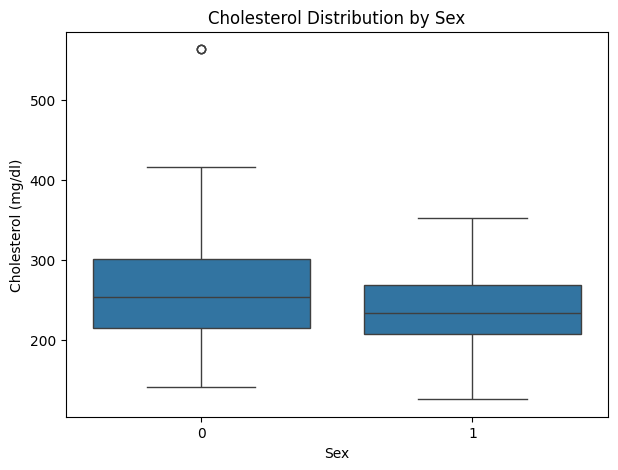

In [123]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x='sex',
    y='chol'
)

plt.title("Cholesterol Distribution by Sex")
plt.xlabel("Sex")
plt.ylabel("Cholesterol (mg/dl)")

plt.show()

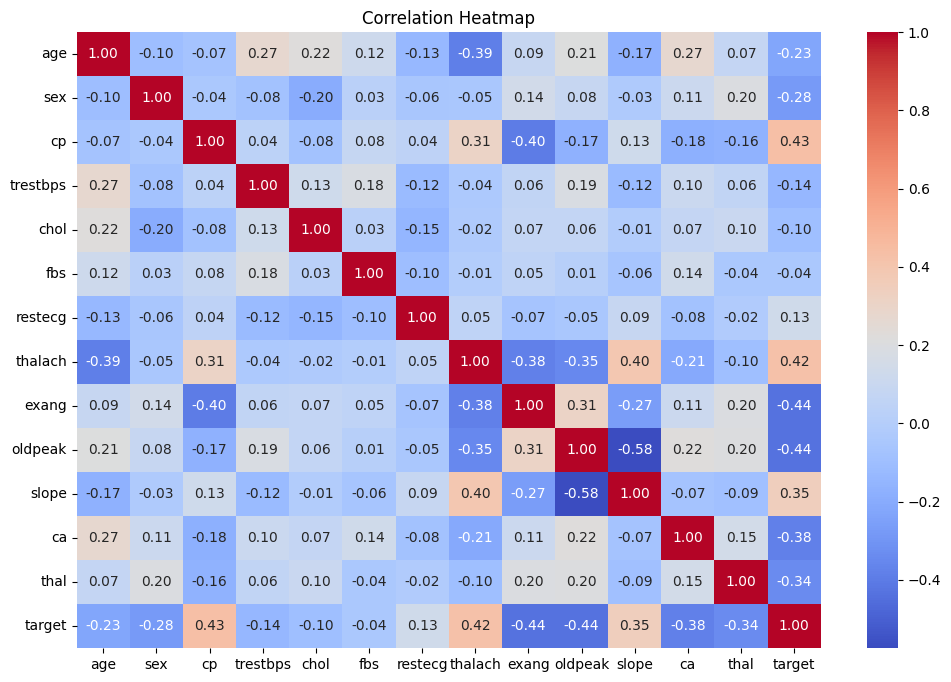

In [124]:
numeric_for_corr = df.copy()

numeric_for_corr = numeric_for_corr.replace('?', np.nan)

for column in numeric_for_corr.columns:
    numeric_for_corr[column] = pd.to_numeric(
        numeric_for_corr[column],
        errors='coerce'
    )

plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_for_corr.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

In [125]:
clean_df = df.copy()

print("Original dataset shape:", clean_df.shape)

Original dataset shape: (1025, 14)


In [126]:
clean_df = clean_df.replace('?', np.nan)

print("Missing values after converting '?' to NaN:")
print(clean_df.isnull().sum())

Missing values after converting '?' to NaN:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [127]:
missing_rows = clean_df[clean_df.isnull().any(axis=1)]

print("Number of rows containing missing values:", len(missing_rows))

missing_rows.head()

Number of rows containing missing values: 0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target


In [128]:
categorical_columns = [
    'sex',
    'cp',
    'fbs',
    'restecg',
    'exang',
    'slope',
    'thal',
    'target'
]

In [129]:
numerical_columns = [
    'age',
    'trestbps',
    'chol',
    'thalach',
    'oldpeak',
    'ca'
]
for column in numerical_columns:
    clean_df[column] = pd.to_numeric(
        clean_df[column],
        errors='coerce'
    )

In [130]:
for column in categorical_columns:
    clean_df[column] = clean_df[column].astype('string')

In [131]:
print(clean_df.dtypes)

age                  int64
sex         string[python]
cp          string[python]
trestbps             int64
chol                 int64
fbs         string[python]
restecg     string[python]
thalach              int64
exang       string[python]
oldpeak            float64
slope       string[python]
ca                   int64
thal        string[python]
target      string[python]
dtype: object


In [132]:
print("Missing values:")
print(clean_df.isnull().sum())

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [133]:
for column in numerical_columns:
    clean_df[column] = clean_df[column].fillna(
        clean_df[column].median()
    )

In [134]:
for column in categorical_columns:
    clean_df[column] = clean_df[column].fillna(
        clean_df[column].mode()[0]
    )

In [135]:
print("Missing values after imputation:")
print(clean_df.isnull().sum())

Missing values after imputation:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [136]:
duplicate_count = clean_df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 723


In [137]:
clean_df = clean_df.drop_duplicates()

print("Shape after removing duplicates:", clean_df.shape)

Shape after removing duplicates: (302, 14)


In [138]:
clean_df[numerical_columns].describe()

,age,trestbps,chol,thalach,oldpeak,ca
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,131.602649,246.500000,149.569536,1.043046,0.718543
std,9.04797,17.563394,51.753489,22.903527,1.161452,1.006748
min,29.00000,94.000000,126.000000,71.000000,0.000000,0.000000
25%,48.00000,120.000000,211.000000,133.250000,0.000000,0.000000
50%,55.50000,130.000000,240.500000,152.500000,0.800000,0.000000
75%,61.00000,140.000000,274.750000,166.000000,1.600000,1.000000
max,77.00000,200.000000,564.000000,202.000000,6.200000,4.000000


In [139]:
for column in numerical_columns:

    Q1 = clean_df[column].quantile(0.25)
    Q3 = clean_df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = clean_df[
        (clean_df[column] < lower_limit) |
        (clean_df[column] > upper_limit)
    ]

    print("\nColumn:", column)
    print("Lower limit:", lower_limit)
    print("Upper limit:", upper_limit)
    print("Number of statistical outliers:", len(outliers))


Column: age
Lower limit: 28.5
Upper limit: 80.5
Number of statistical outliers: 0

Column: trestbps
Lower limit: 90.0
Upper limit: 170.0
Number of statistical outliers: 9

Column: chol
Lower limit: 115.375
Upper limit: 370.375
Number of statistical outliers: 5

Column: thalach
Lower limit: 84.125
Upper limit: 215.125
Number of statistical outliers: 1

Column: oldpeak
Lower limit: -2.4000000000000004
Upper limit: 4.0
Number of statistical outliers: 5

Column: ca
Lower limit: -1.5
Upper limit: 2.5
Number of statistical outliers: 24


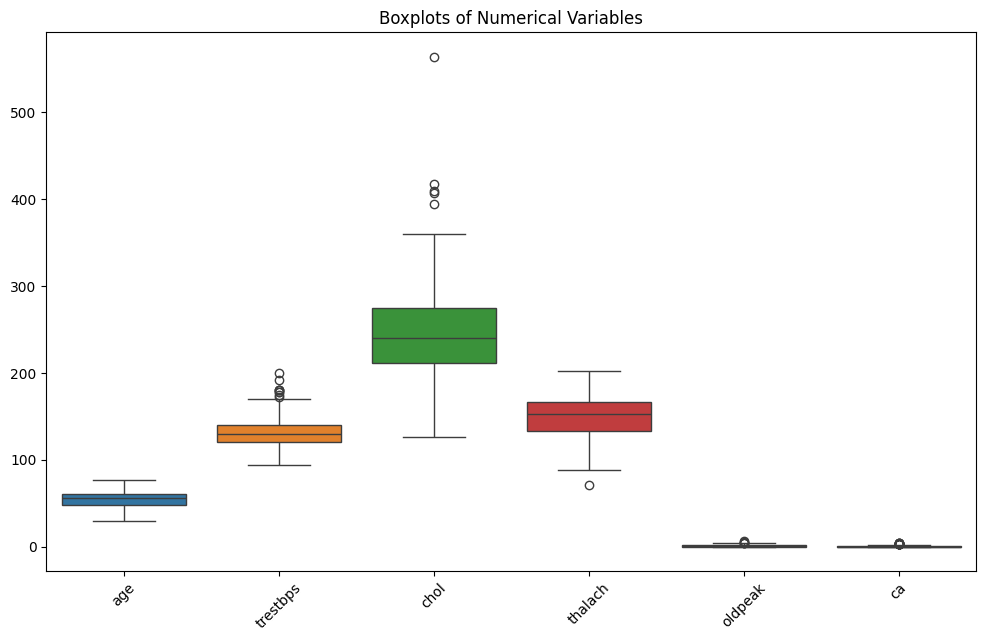

In [140]:
plt.figure(figsize=(12, 7))

sns.boxplot(data=clean_df[numerical_columns])

plt.title("Boxplots of Numerical Variables")
plt.xticks(rotation=45)

plt.show()

In [141]:
clean_df['cardiovascular_load'] = (
    clean_df['age'] * clean_df['thalach']
)

In [142]:
print(
    clean_df[
        ['age', 'thalach', 'cardiovascular_load', 'chol']
    ].head(10)
)

   age  thalach  cardiovascular_load  chol
0   52      168                 8736   212
1   53      155                 8215   203
2   70      125                 8750   174
3   61      161                 9821   203
4   62      106                 6572   294
5   58      122                 7076   248
6   58      140                 8120   318
7   55      145                 7975   289
8   46      144                 6624   249
9   54      116                 6264   286


In [143]:
print(clean_df['cardiovascular_load'].describe())

count      302.000000
mean      8058.019868
std       1471.723696
min       4550.000000
25%       6969.750000
50%       8134.000000
75%       9106.000000
max      12474.000000
Name: cardiovascular_load, dtype: float64


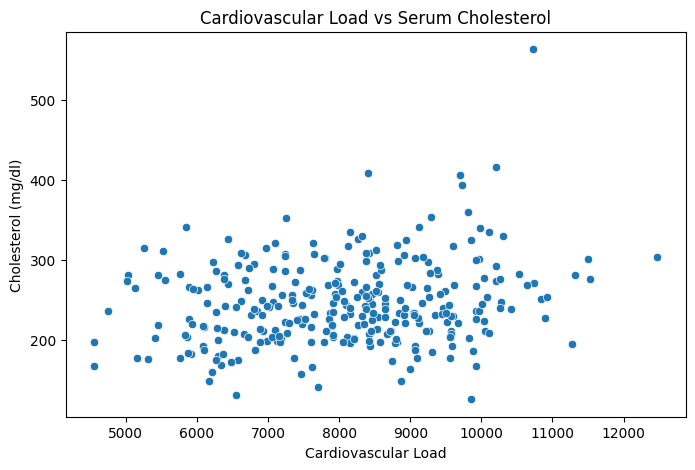

In [144]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=clean_df,
    x='cardiovascular_load',
    y='chol'
)

plt.title("Cardiovascular Load vs Serum Cholesterol")
plt.xlabel("Cardiovascular Load")
plt.ylabel("Cholesterol (mg/dl)")

plt.show()

In [145]:
print(
    clean_df[
        ['age', 'thalach', 'cardiovascular_load', 'chol']
    ].corr()
)

                          age   thalach  cardiovascular_load      chol
age                  1.000000 -0.395235             0.605224  0.207216
thalach             -0.395235  1.000000             0.480106 -0.005308
cardiovascular_load  0.605224  0.480106             1.000000  0.206556
chol                 0.207216 -0.005308             0.206556  1.000000


In [146]:
X = clean_df.drop(columns=['chol'])
y = clean_df['chol']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (302, 14)
Target shape: (302,)


In [147]:
print("Features:")
print(X.columns.tolist())

Features:
['age', 'sex', 'cp', 'trestbps', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target', 'cardiovascular_load']


In [148]:
X_encoded = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True,
    dtype=float
)

In [149]:
print("Encoded feature shape:", X_encoded.shape)

X_encoded.head()

Encoded feature shape: (302, 20)


,age,trestbps,thalach,oldpeak,ca,cardiovascular_load,sex_1,cp_1,cp_2,cp_3,fbs_1,restecg_1,restecg_2,exang_1,slope_1,slope_2,thal_1,thal_2,thal_3,target_1
0,52,125,168,1.0,2,8736,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,53,140,155,3.1,0,8215,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,70,145,125,2.6,0,8750,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,61,148,161,0.0,1,9821,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,62,138,106,1.9,3,6572,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [150]:
print("Missing values in features:")
print(X_encoded.isnull().sum().sum())

print("Missing values in target:")
print(y.isnull().sum())

Missing values in features:
0
Missing values in target:
0


In [151]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features :", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target :", y_test.shape)

Training features: (241, 20)
Testing features : (61, 20)
Training target: (241,)
Testing target : (61,)


In [152]:
model = LinearRegression()

In [153]:
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [154]:
y_pred = model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[240.89493143 245.41605091 306.30796567 242.1324374  225.4091524
 255.58976313 249.21107972 222.1907501  238.78042373 234.95488641]


In [155]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: -0.17660297728099006


In [156]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 35.47215850409595


In [157]:
print("=" * 45)
print("LINEAR REGRESSION MODEL PERFORMANCE")
print("=" * 45)

print(f"R² Score : {r2:.4f}")
print(f"MAE      : {mae:.4f}")

LINEAR REGRESSION MODEL PERFORMANCE
R² Score : -0.1766
MAE      : 35.4722


In [158]:
results = pd.DataFrame({
    'Actual Cholesterol': y_test.values,
    'Predicted Cholesterol': y_pred
})

results.head(10)

,Actual Cholesterol,Predicted Cholesterol
0,219,240.894931
1,263,245.416051
2,225,306.307966
3,233,242.132437
4,197,225.409152
5,286,255.589763
6,167,249.211080
7,273,222.190750
8,239,238.780424
9,231,234.954886


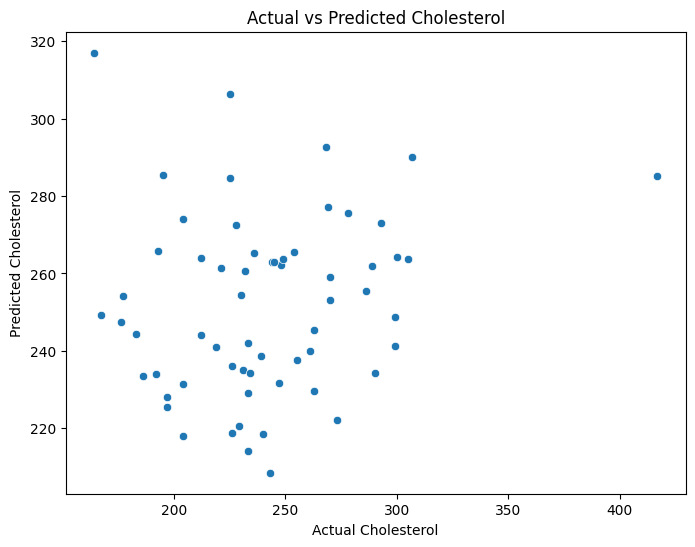

In [159]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred
)

plt.xlabel("Actual Cholesterol")
plt.ylabel("Predicted Cholesterol")
plt.title("Actual vs Predicted Cholesterol")

plt.show()

In [160]:
coefficients = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Coefficient': model.coef_
})

coefficients

,Feature,Coefficient
0,age,-2.575739
1,trestbps,0.223659
2,thalach,-0.988388
3,oldpeak,6.085761
4,ca,2.116609
5,cardiovascular_load,0.022263
6,sex_1,-28.128058
7,cp_1,4.932767
8,cp_2,-8.430921
9,cp_3,-13.421383


In [161]:
coefficients['Absolute_Coefficient'] = coefficients['Coefficient'].abs()

coefficients
sorted_coefficients = coefficients.sort_values(
    by='Absolute_Coefficient',
    ascending=False
)

sorted_coefficients

,Feature,Coefficient,Absolute_Coefficient
18,thal_3,40.599493,40.599493
16,thal_1,37.268663,37.268663
17,thal_2,32.858579,32.858579
6,sex_1,-28.128058,28.128058
15,slope_2,17.781394,17.781394
11,restecg_1,-16.831605,16.831605
14,slope_1,13.879578,13.879578
12,restecg_2,-13.827034,13.827034
9,cp_3,-13.421383,13.421383
8,cp_2,-8.430921,8.430921


In [162]:
top_3 = sorted_coefficients.head(3)

print("Top 3 features based on absolute coefficient:")
print(top_3[['Feature', 'Coefficient']].to_string(index=False))

Top 3 features based on absolute coefficient:
Feature  Coefficient
 thal_3    40.599493
 thal_1    37.268663
 thal_2    32.858579


In [163]:
for index, row in top_3.iterrows():

    feature = row['Feature']
    coefficient = row['Coefficient']

    print(
        f"{feature}: coefficient = {coefficient:.4f}"
    )

thal_3: coefficient = 40.5995
thal_1: coefficient = 37.2687
thal_2: coefficient = 32.8586


In [164]:
for index, row in top_3.iterrows():

    feature = row['Feature']
    coefficient = row['Coefficient']

    if coefficient > 0:
        direction = "positive"
    else:
        direction = "negative"

    print(
        f"{feature} has a {direction} coefficient "
        f"of {coefficient:.4f}."
    )

thal_3 has a positive coefficient of 40.5995.
thal_1 has a positive coefficient of 37.2687.
thal_2 has a positive coefficient of 32.8586.


In [165]:
print("=" * 60)
print("FINAL ML TASK SUMMARY")
print("=" * 60)

print("\nOriginal Dataset Shape:")
print(df.shape)

print("\nCleaned Dataset Shape:")
print(clean_df.shape)

print("\nNumber of Features Used:")
print(X_encoded.shape[1])

print("\nTrain-Test Split:")
print("80% Training")
print("20% Testing")

print("\nModel:")
print("Linear Regression")

print("\nModel Performance:")
print(f"R² Score : {r2:.4f}")
print(f"MAE      : {mae:.4f}")

print("\nTop 3 Features:")
print(top_3[['Feature', 'Coefficient']].to_string(index=False))

FINAL ML TASK SUMMARY

Original Dataset Shape:
(1025, 14)

Cleaned Dataset Shape:
(302, 15)

Number of Features Used:
20

Train-Test Split:
80% Training
20% Testing

Model:
Linear Regression

Model Performance:
R² Score : -0.1766
MAE      : 35.4722

Top 3 Features:
Feature  Coefficient
 thal_3    40.599493
 thal_1    37.268663
 thal_2    32.858579
